<a href="https://colab.research.google.com/github/epythonlab2/AI_4_health/blob/main/module_2_model_deployment_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<header style="font-family: 'Inter', sans-serif; background: #ffffff; padding: 16px; border-radius: 8px; border: 1px solid #e1e4e8; display: flex; align-items: center; gap: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); margin-bottom: 10px;">
    <div style="width: 4px; height: 35px; background: linear-gradient(to bottom, #4e73df, #1cc88a); border-radius: 2px;"></div>
    <h1 style="color: #1a1a1a; margin: 0; font-size: 20px; font-weight: 700; border: none;"><strong>Module 2: Machine Learning and Statistics</strong></h1>
</header>

<div style="font-family: 'Inter', sans-serif; max-width: 900px; margin: 15px 0; padding: 20px; border-radius: 10px; background: #f1f4ff; border: 1px solid #dbe3ff; display: flex; align-items: center; justify-content: space-between; gap: 15px;">
    <div style="flex: 1;">
        <h2 style="margin: 0; color: #2e59d9; font-size: 18px; font-weight: 700; border: none;"><strong>Chapter 4: Model Deployment & Interpretability</strong></h2>
        <span style="display: inline-block; margin-top: 8px; background: #ffffff; padding: 4px 12px; border-radius: 6px; color: #4e73df; font-weight: 800; font-size: 11px; border: 1px solid #dbe3ff; text-transform: uppercase;">6 Hours</span>
    </div>

   <a href="https://linkedin.com/in/dejenet" target="_blank" style="background-color: #0077b5; color: white; padding: 10px 20px; border-radius: 8px; text-decoration: none; font-size: 14px; font-weight: 700; white-space: nowrap;">
        Connect on LinkedIn
    </a>
</div>

###**4.1 Saving and Loading Machine Learning Models**

Once a machine learning model is trained, it must be saved so it can be reused without retraining. This is essential for deployment, reproducibility, and version control.

In Python, the most common tools for this are **joblib** and **pickle**. For scikit-learn models, **joblib** is generally preferred because it handles large numerical arrays efficiently.

#### **4.2 Load Breat Cancer Dataset**
Let's pause the saving and loading ml model, load the best clean datasets (No Data Cleaning Needed)

**Why this is the top choice**

- Comes pre-cleaned with scikit-learn

- No missing values

- All numeric

- Clear medical meaning

- Works perfectly with **Flask** + **SHAP**

In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names


In [4]:
feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [9]:
print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

**Use case**

- Classification API

- Feature importance visualization

- Zero preprocessing

- Great for demos and teaching

**1. Split and Train**
First, we split the data into a training set to "teach" the model and a testing set to "verify" its performance.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

**2. Evaluate the Results**

For medical data, we don't just care about overall accuracy; we care about Precision and Recall (to ensure we aren't missing true positive cases).

In [11]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[40  3]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



**3. Feature Importance**

One of the best parts of using a Random Forest is seeing which features the model relied on most to make a decision.

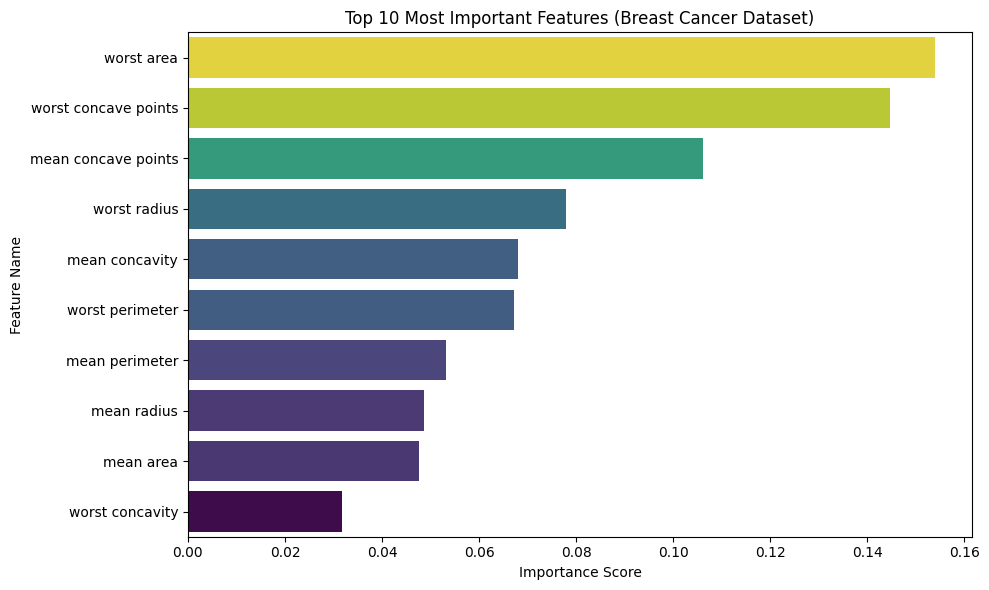

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Create a DataFrame for the importances
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 2. Sort and select the top 10 for better readability
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance_df,
            hue="Importance",
            legend=False,
            palette='viridis')

plt.title('Top 10 Most Important Features (Breast Cancer Dataset)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

**Key Concepts Applied**
- `train_test_split:` Prevents "overfitting" by ensuring the model is tested on data it has never seen before.
- $n\_estimators=100$: This tells the model to build 100 individual decision trees and average their results.
- Random State: Setting this to a fixed number (like 42) ensures your results are reproducible every time you run the code.